___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Autoencoder Exercise

## Complete the Tasks Below

**TASK: Run the imports below**

In [1]:
import numpy as np
import pandas as pd

#%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set_style("darkgrid")

%config InlineBackened.format_figure = "svg"

## The Data

 In the table is the average consumption of 17 types of food in grams per person per week for every country in the UK.

The table shows some interesting variations across different food types, but overall differences aren't so notable. 

**TASK: Run the import line below to read in the data**

In [2]:
df = pd.read_csv('../DATA/UK_foods.csv',index_col='Unnamed: 0')

**TASK: Display the DataFrame**

In [3]:
#CODE HERE
df

,England,Wales,Scotland,N.Ireland
Cheese,105,103,103,66
Carcass_meat,245,227,242,267
Other_meat,685,803,750,586
Fish,147,160,122,93
Fats_and_oils,193,235,184,209
Sugars,156,175,147,139
Fresh_potatoes,720,874,566,1033
Fresh_Veg,253,265,171,143
Other_Veg,488,570,418,355
Processed_potatoes,198,203,220,187


**TASK: Transpose the DataFrame so that the columns are now the index.**

In [4]:
#CODE HERE
df = df.T
df

,Cheese,Carcass_meat,Other_meat,Fish,Fats_and_oils,Sugars,Fresh_potatoes,Fresh_Veg,Other_Veg,Processed_potatoes,Processed_Veg,Fresh_fruit,Cereals,Beverages,Soft_drinks,Alcoholic_drinks,Confectionery
England,105,245,685,147,193,156,720,253,488,198,360,1102,1472,57,1374,375,54
Wales,103,227,803,160,235,175,874,265,570,203,365,1137,1582,73,1256,475,64
Scotland,103,242,750,122,184,147,566,171,418,220,337,957,1462,53,1572,458,62
N.Ireland,66,267,586,93,209,139,1033,143,355,187,334,674,1494,47,1506,135,41


**TASK: Create a heatmap from the DataFrame. Does any country really stand out as different than the others? It should be tricky to tell just from the image. Do any two countries appear to be very similar?**

In [5]:
df.T.max()

England      1472
Wales        1582
Scotland     1572
N.Ireland    1506
dtype: int64

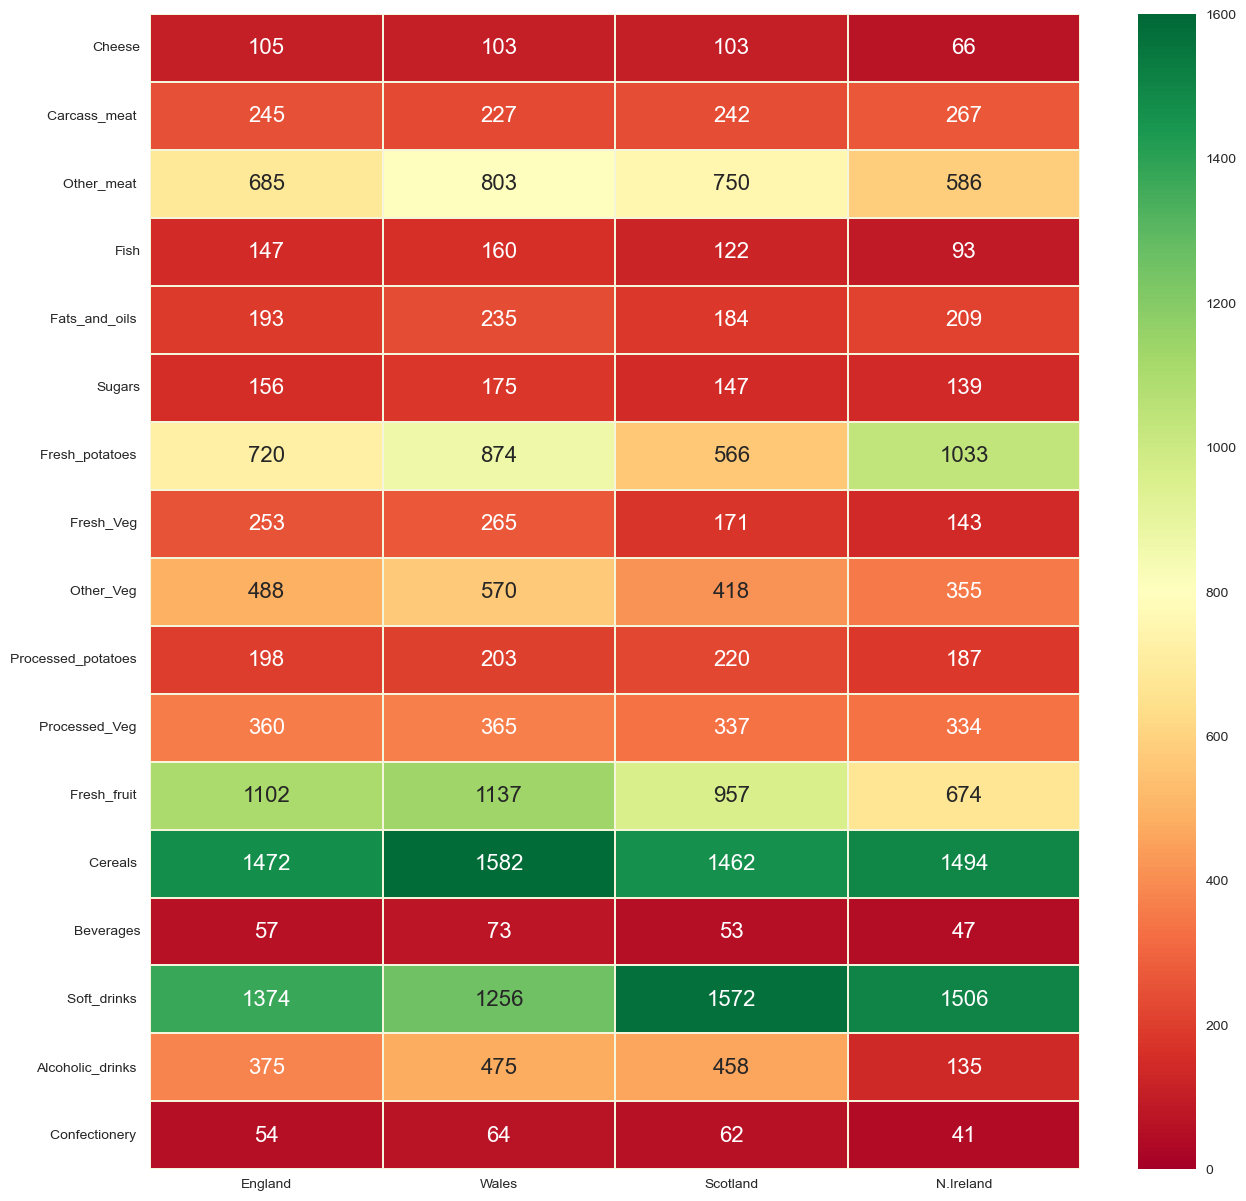

In [6]:
#CODE HERE
plt.figure(figsize=(15,15))
sns.heatmap(df.T , 
            vmax=1600 , 
            vmin = 0 , 
            annot = True , 
            linewidths= 0.2,
            linecolor='beige', 
            annot_kws={"fontsize":16} , 
            cmap='RdYlGn',    
            fmt = "2g")
sns.despine()

**TASK: Run the imports necessary to build an autoencoder. Our goal will be to reduce the dimensions from 17 --> 2 and see if any countries stand out as very different.**

In [7]:
#CODE HERE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import MSE

In [8]:
len(df.columns)

17

**TASK: Create an encoder. In the solutions we built one that went 17 --> 8 --> 4 --> 2**

In [9]:
#CODE HERE
encoder = Sequential()
encoder.add(Dense(units=8 , input_shape = [17] , activation='relu'))
encoder.add(Dense(units=4 , activation='relu'))
encoder.add(Dense(units=2 , activation='relu'))

c:\Users\ahmad\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**TASK: Create a decoder. In the solutions we built one that went 2-->4-->8-->17**

In [10]:
#CODE HERE
decoder = Sequential()
decoder.add(Dense(units=4 , input_shape = [2], activation='relu'))
decoder.add(Dense(units=8 , activation='relu'))
decoder.add(Dense(units=17 , activation='relu'))

**TASK: Combine the encoder and decoder to be an autoencoder and compile the model.**

In [11]:
#CODE HERE
autoencoder = Sequential([encoder , decoder])
autoencoder.compile(optimizer = SGD(learning_rate=1.5), loss =MSE)

**TASK: Create a MinMaxScaler to scale the data. Make sure to transpose the data, since we really have 17 feature columns and only 4 rows (one per country).**

In [12]:
#CODE HERE
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)

In [13]:
scaled_df.shape

(4, 17)

In [14]:
scaled_df

array([[1.        , 0.45      , 0.4562212 , 0.80597015, 0.17647059,
        0.47222222, 0.32976445, 0.90163934, 0.61860465, 0.33333333,
        0.83870968, 0.92440605, 0.08333333, 0.38461538, 0.37341772,
        0.70588235, 0.56521739],
       [0.94871795, 0.        , 1.        , 1.        , 1.        ,
        1.        , 0.65952891, 1.        , 1.        , 0.48484848,
        1.        , 1.        , 1.        , 1.        , 0.        ,
        1.        , 1.        ],
       [0.94871795, 0.375     , 0.75576037, 0.43283582, 0.        ,
        0.22222222, 0.        , 0.2295082 , 0.29302326, 1.        ,
        0.09677419, 0.6112311 , 0.        , 0.23076923, 1.        ,
        0.95      , 0.91304348],
       [0.        , 1.        , 0.        , 0.        , 0.49019608,
        0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.26666667, 0.        , 0.79113924,
        0.        , 0.        ]])

**TASK: Fit the autoencoder to the scaled data for 15 epochs.**

In [15]:
#CODE HERE
autoencoder.fit(scaled_df , scaled_df , epochs=15)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 0.4230
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3665
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2773
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2909
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2094
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1843
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1743
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1681
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1663
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1719
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2183
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1686
Epoch 13/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1974
Epoch 14/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1702
Epoch 15/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2160


In [16]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 2)              │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 17)             │           205 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397 (1.55 KB)

 Trainable params: 395 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

<Axes: >

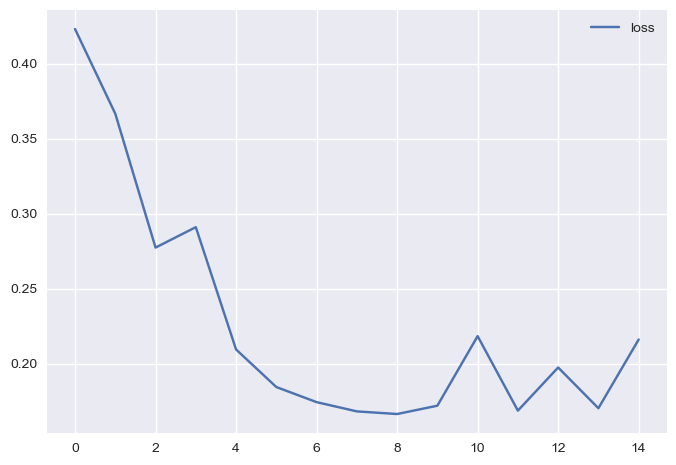

In [17]:
pd.DataFrame(autoencoder.history.history).plot()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


(4, 2)

**TASK: Run the scaled data through only the encoder and predict the reduced dimensionalty output. Note: You will most likely get different results than us due to random initialiations.**

In [22]:
#CODE HERE
reduced_dimension = encoder.predict(scaled_df)
reduced_dimension.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


(4, 2)

In [23]:
reduced_dimension

array([[1.9140936e+00, 0.0000000e+00],
       [2.8390353e+00, 0.0000000e+00],
       [1.2107749e+00, 0.0000000e+00],
       [0.0000000e+00, 8.1624836e-04]], dtype=float32)

**TASK: Join the encoded 2 dimensional data with the original countries index. Triple check the index order to make sure its joined correctly. There are many ways to do this with pandas.**

In [25]:
df.index

Index(['England', 'Wales', 'Scotland', 'N.Ireland'], dtype='str')

In [54]:
#Code here
reduced_dimension_df = pd.DataFrame(reduced_dimension , index=df.index , columns=["C1","C2"])
reduced_dimension_df.index.name = "Index"
reduced_dimension_df.reset_index(inplace=True)
reduced_dimension_df

,Index,C1,C2
0,England,1.914094,0.000000
1,Wales,2.839035,0.000000
2,Scotland,1.210775,0.000000
3,N.Ireland,0.000000,0.000816


**TASK: Now plot out these results in a scatterplot, labeled by their respective country. You should see N. Ireland further away from the other points (but not necessarily to the left or the right, could be centered further away from the others).**

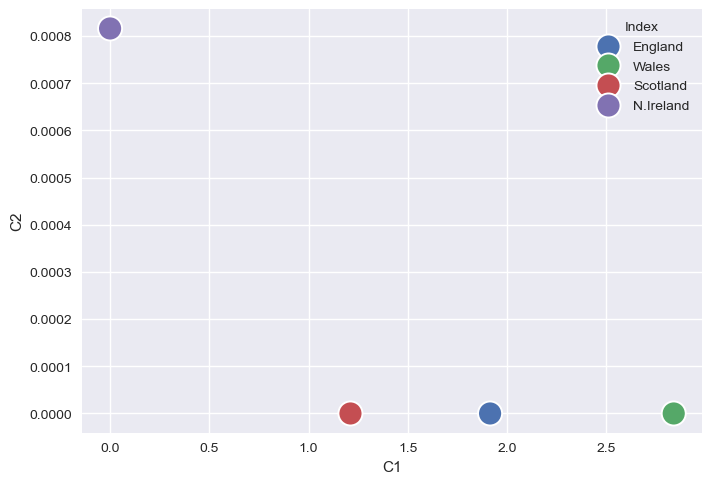

In [68]:
#CODE HERE
sns.scatterplot(data = reduced_dimension_df  , 
                x = "C1", 
                y = "C2",
                hue = "Index",
                s=300)
sns.despine()

 Once we go back and look at the data in the table, this makes sense: the Northern Irish eat way more grams of fresh potatoes and way fewer of fresh fruits, cheese, fish and alcoholic drinks. It's a good sign that structure we've visualized reflects a big fact of real-world geography: Northern Ireland is the only of the four countries not on the island of Great Britain. (If you're confused about the differences among England, the UK and Great Britain, see: this [video](https://www.youtube.com/watch?v=rNu8XDBSn10).)